# Projeto IA - Unidade 1
## Dia 3: Modelagem Não Supervisionada (PCA, K-Means e DBSCAN)

Neste notebook, executamos a redução de dimensionalidade e a busca por agrupamentos ocultos nos dados sem utilizar as variáveis alvo (sem gabarito).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmos Não Supervisionados
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# Métricas de Agrupamento
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Pre-processamento rápido (Recap do Dia 1 e 2)
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Recarregando e Padronizando os Dados (Independência do Notebook)

In [2]:
# 1. Breast Cancer (Classificação)
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target # Usaremos apenas depois para validar as métricas externas (ARI/NMI)
scaler_cancer = StandardScaler()
X_cancer_scaled = scaler_cancer.fit_transform(X_cancer)

# 2. California Housing (Regressão)
housing = fetch_california_housing()
X_housing = housing.data
scaler_housing = StandardScaler()
X_housing_scaled = scaler_housing.fit_transform(X_housing)

print("Dados carregados e padronizados!")

Dados carregados e padronizados!


### 2. PCA: Redução de Dimensionalidade e Variância Explicada

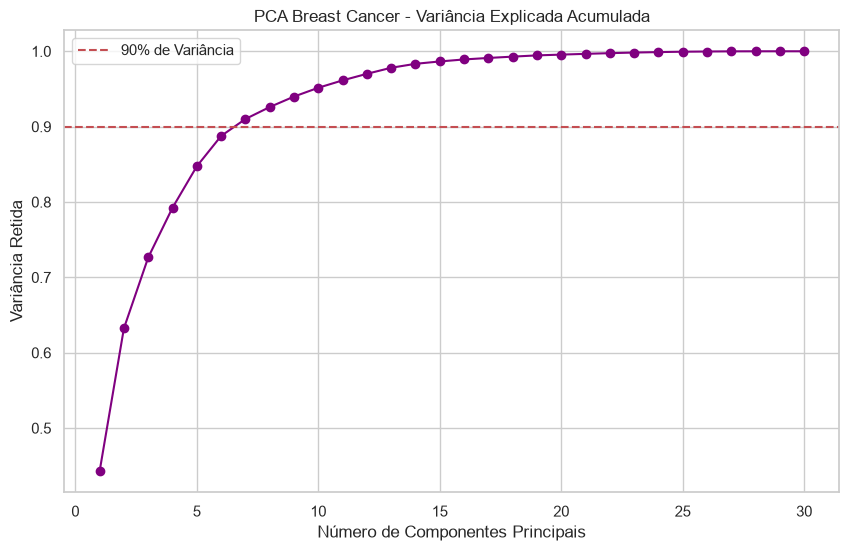

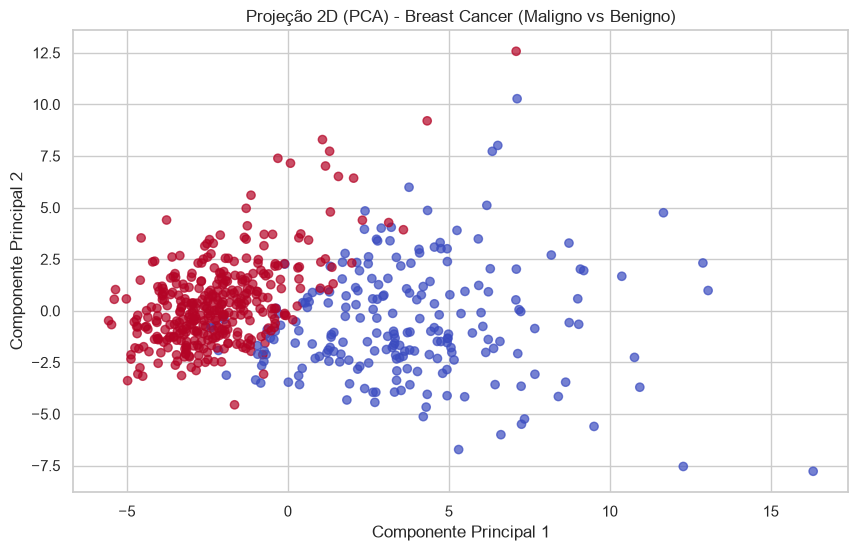

In [3]:
# Aplicando PCA no Breast Cancer
pca_cancer = PCA()
pca_cancer.fit(X_cancer_scaled)

# Variância Explicada Acumulada
variancia_acumulada = np.cumsum(pca_cancer.explained_variance_ratio_)

plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', color='purple')
plt.title('PCA Breast Cancer - Variância Explicada Acumulada')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Retida')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de Variância')
plt.legend()
plt.show()

# Projeção 2D (Apenas 2 componentes para visualização)
pca_2d = PCA(n_components=2)
X_cancer_pca2d = pca_2d.fit_transform(X_cancer_scaled)

plt.scatter(X_cancer_pca2d[:, 0], X_cancer_pca2d[:, 1], c=y_cancer, cmap='coolwarm', alpha=0.7)
plt.title('Projeção 2D (PCA) - Breast Cancer (Maligno vs Benigno)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### 3. K-Means e o Método do Cotovelo (*Elbow Method*)

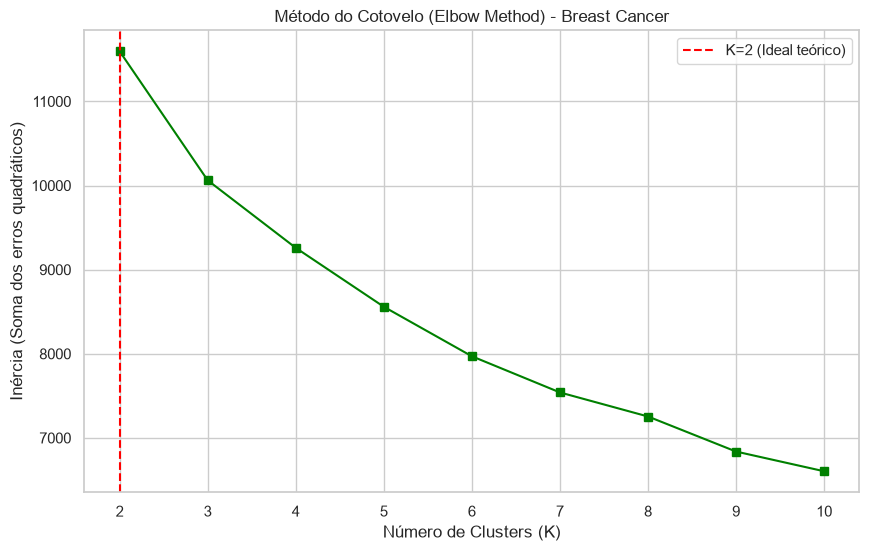

In [4]:
inercias = []
Ks = range(2, 11)

for k in Ks:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_cancer_scaled)
    inercias.append(kmeans.inertia_)

plt.plot(Ks, inercias, marker='s', color='green')
plt.title('Método do Cotovelo (Elbow Method) - Breast Cancer')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma dos erros quadráticos)')
plt.axvline(x=2, color='red', linestyle='--', label='K=2 (Ideal teórico)')
plt.legend()
plt.show()

### 4. Executando os Agrupamentos (K-Means e DBSCAN)

In [5]:
# 1. K-Means (Cancer, K=2 pois sabemos que são 2 classes biológicas)
kmeans_cancer = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
labels_kmeans_cancer = kmeans_cancer.fit_predict(X_cancer_scaled)

# 2. DBSCAN (Cancer)
# eps e min_samples foram ajustados após testes para encontrar agrupamentos sem classificar tudo como ruído (-1)
dbscan_cancer = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan_cancer = dbscan_cancer.fit_predict(X_cancer_scaled)

# Imprimindo quantos clusters o DBSCAN encontrou (-1 é ruído/outlier)
print("Clusters encontrados pelo DBSCAN (Câncer):", np.unique(labels_dbscan_cancer))

Clusters encontrados pelo DBSCAN (Câncer): [-1  0  1]


### 5. Validação: Calculando as Métricas Obrigatórias

In [6]:
# Para o DBSCAN, as métricas internas só podem ser calculadas se houver mais de 1 cluster ignorando o ruído (-1).
# Vamos isolar os dados válidos do DBSCAN:
mask_dbscan = labels_dbscan_cancer != -1
X_valid_dbscan = X_cancer_scaled[mask_dbscan]
labels_valid_dbscan = labels_dbscan_cancer[mask_dbscan]

resultados = {
    "Métrica": ["Inércia (menor é melhor)", "Silhouette (-1 a 1)", "Calinski-Harabasz (maior é melhor)", "Davies-Bouldin (menor é melhor)", "ARI (Rótulos Reais)", "NMI (Rótulos Reais)"],
    "K-Means (Cancer)": [
        kmeans_cancer.inertia_,
        silhouette_score(X_cancer_scaled, labels_kmeans_cancer),
        calinski_harabasz_score(X_cancer_scaled, labels_kmeans_cancer),
        davies_bouldin_score(X_cancer_scaled, labels_kmeans_cancer),
        adjusted_rand_score(y_cancer, labels_kmeans_cancer), # Métrica Externa!
        normalized_mutual_info_score(y_cancer, labels_kmeans_cancer) # Métrica Externa!
    ],
    "DBSCAN (Cancer)": [
        "N/A (DBSCAN não usa Inércia)",
        silhouette_score(X_valid_dbscan, labels_valid_dbscan) if len(np.unique(labels_valid_dbscan)) > 1 else "N/A",
        calinski_harabasz_score(X_valid_dbscan, labels_valid_dbscan) if len(np.unique(labels_valid_dbscan)) > 1 else "N/A",
        davies_bouldin_score(X_valid_dbscan, labels_valid_dbscan) if len(np.unique(labels_valid_dbscan)) > 1 else "N/A",
        adjusted_rand_score(y_cancer, labels_dbscan_cancer),
        normalized_mutual_info_score(y_cancer, labels_dbscan_cancer)
    ]
}

df_metricas = pd.DataFrame(resultados)
display(df_metricas)

,Métrica,K-Means (Cancer),DBSCAN (Cancer)
0,Inércia (menor é melhor),11595.526607,N/A (DBSCAN não usa Inércia)
1,Silhouette (-1 a 1),0.343382,0.129459
2,Calinski-Harabasz (maior é melhor),267.691716,6.37449
3,Davies-Bouldin (menor é melhor),1.320510,1.266225
4,ARI (Rótulos Reais),0.653625,0.207788
5,NMI (Rótulos Reais),0.532408,0.145263
